### imports

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import measure
import pandas as pd
from config import get_control_file


plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})


### array to df

In [117]:
# load npy file for participant
participant = 1
trial_number = 5
file_path = get_control_file(participant)
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

def participant_pupil_stats(data):
    pupil_chunks = []
    n_trials = data.shape[2]
    for idx in range(n_trials):
        trial_pupil = data[2, :, idx].astype(float)
        p_mu = np.nanmean(trial_pupil)
        p_sigma = np.nanstd(trial_pupil)
        if np.isfinite(p_mu) and np.isfinite(p_sigma) and p_sigma > 0:
            trial_pupil_z = (trial_pupil - p_mu) / p_sigma
        else:
            trial_pupil_z = np.full_like(trial_pupil, np.nan, dtype=float)
        mask = trial_pupil_z < -2.0
        mask = ndimage.binary_dilation(mask, iterations=15)
        trial_pupil = trial_pupil.copy()
        trial_pupil[mask] = np.nan
        trial_pupil = trial_pupil[np.isfinite(trial_pupil)]
        if trial_pupil.size > 0:
            pupil_chunks.append(trial_pupil)

    if pupil_chunks:
        pooled = np.concatenate(pupil_chunks)
        return float(np.nanmean(pooled)), float(np.nanstd(pooled))
    return np.nan, np.nan

pupil_mu, pupil_sigma = participant_pupil_stats(data)
if np.isfinite(pupil_mu) and np.isfinite(pupil_sigma) and pupil_sigma > 0:
    df['pupil_z'] = (df['pupil'] - pupil_mu) / pupil_sigma
else:
    df['pupil_z'] = np.nan




### pupil dilation

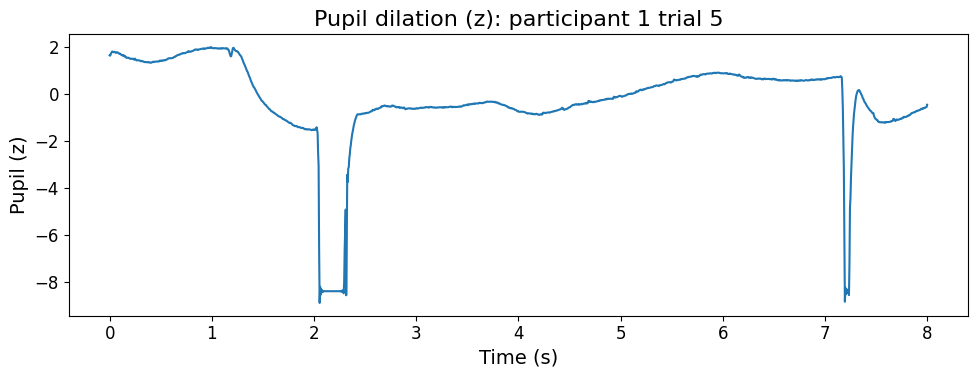

In [118]:
fs = 200  # sampling frequency Hz
samples = data.shape[1]

time = np.arange(samples) / fs

plt.figure(figsize=(10,4))
plt.plot(time, df['pupil_z'])
plt.title(f'Pupil dilation (z): participant {participant} trial {trial_number}')
plt.xlabel('Time (s)')
plt.ylabel('Pupil (z)')
plt.tight_layout()
plt.show()



### blink check

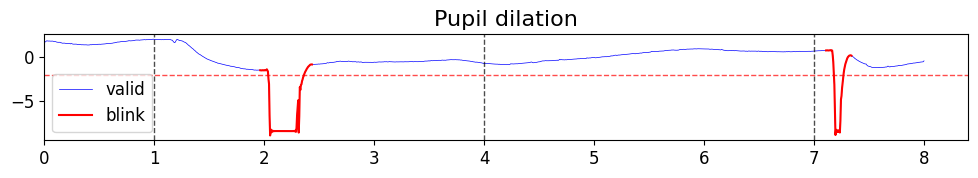

In [119]:
blink_mask = df['pupil_z'] < -2.0 # True = blink, False = valid (z threshold)
blink_mask = ndimage.binary_dilation(blink_mask, iterations=15)
time = np.arange(samples) / fs

t_fix_start, t_fix_end, t_cue_end = 1.0, 4.0, 7.0

plt.figure(figsize=(10,2))

blink_p = np.where(blink_mask, df['pupil_z'], np.nan)  # non-blink points become gaps
plt.plot(time, df['pupil_z'], color='blue', label='valid', lw = 0.5)
plt.plot(time, blink_p, color='red', label='blink')
for tline in (t_fix_start, t_fix_end, t_cue_end):
    plt.axvline(tline, color='k', linestyle='--', linewidth=1.0, alpha=0.7)

plt.axhline(y=-2, color='r', linestyle = '--', linewidth=1.0, alpha=0.7)

plt.xlim(left=0)
plt.title('Pupil dilation')
plt.legend()
plt.tight_layout()
plt.show()


### visualising the trial

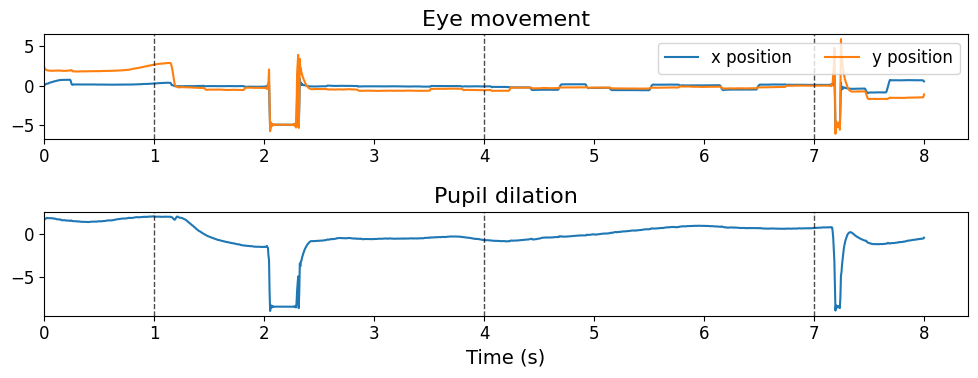

In [120]:
plt.figure(figsize = (10,4))
ax1 = plt.subplot(2,1,1)
ax1.plot(time, df['x'], label = 'x position')
ax1.plot(time, df['y'], label = 'y position')
for tline in (1.0, 4.0, 7.0):
    ax1.axvline(tline, color='k', linestyle='--', linewidth=1.0, alpha=0.7)
ax1.set_xlim(left=0)
ax1.legend(loc = 'upper right', ncol = 2)
ax1.set_title('Eye movement')

ax2 = plt.subplot(2,1,2)
ax2.set_title('Pupil dilation')
ax2.plot(time, df['pupil_z'])
for tline in (1.0, 4.0, 7.0):
    ax2.axvline(tline, color='k', linestyle='--', linewidth=1.0, alpha=0.7)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time (s)')
plt.tight_layout()

plt.show()


### ignoring blinks

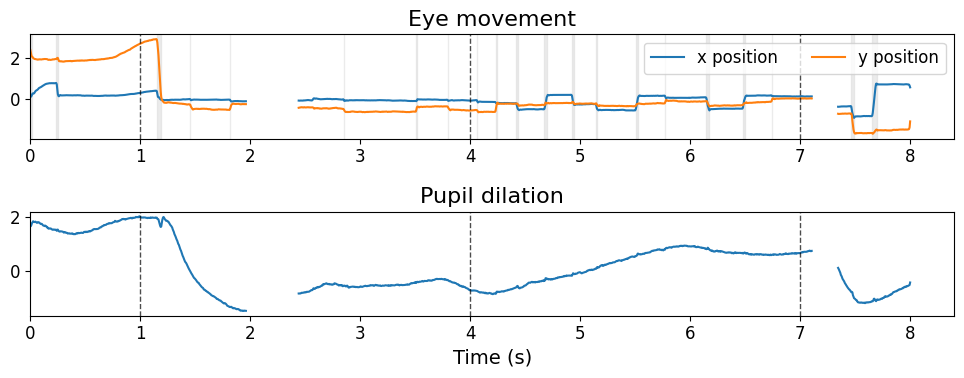

In [121]:
df_clean = df.copy()
df_clean.loc[blink_mask, :] = np.nan

# detect saccade intervals on blink-cleaned eye position
merging_ms = 10
thr_z = 1
iters = max(1, int((merging_ms / 1000.0) * fs))

x = df_clean['x']
y = df_clean['y']
speed = np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)
mu = np.nanmean(speed)
sigma = np.nanstd(speed)
if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0:
    speed_z = (speed - mu) / sigma
else:
    speed_z = np.full_like(speed, np.nan, dtype=float)
raw = speed_z > thr_z
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
labelled, _ = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)
time_speed = np.arange(len(speed)) / fs

t_fix_start, t_fix_end, t_cue_end = 1.0, 4.0, 7.0

plt.figure(figsize = (10,4))
ax1 = plt.subplot(2,1,1)

# shade detected saccades in the background (panel C, first graph)
for r in regions:
    if r is None:
        continue
    start = r[0].start
    stop = r[0].stop
    ax1.axvspan(time_speed[start], time_speed[max(start, stop - 1)], color='0.85', alpha=0.5, zorder=0)

ax1.plot(time, df_clean['x'], label = 'x position')
ax1.plot(time, df_clean['y'], label = 'y position')
for tline in (t_fix_start, t_fix_end, t_cue_end):
    ax1.axvline(tline, color='k', linestyle='--', linewidth=1.0, alpha=0.7)
ax1.set_xlim(left=0)
ax1.legend(loc = 'upper right', ncol = 2)
ax1.set_title('Eye movement')

ax2 = plt.subplot(2,1,2)
ax2.set_title('Pupil dilation')
ax2.plot(time, df_clean['pupil_z'])
for tline in (t_fix_start, t_fix_end, t_cue_end):
    ax2.axvline(tline, color='k', linestyle='--', linewidth=1.0, alpha=0.7)
ax2.set_xlim(left=0)
ax2.set_xlabel('Time (s)')
plt.tight_layout()

plt.show()


### saccade info:

number of saccades = 21


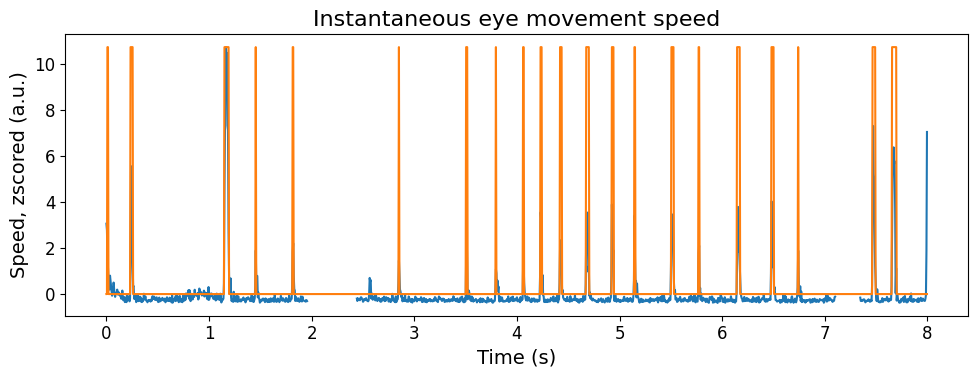

number of saccades = 21
    label  start_s  end_s  duration_ms  mean_speed  max_speed
0       1    0.010  0.015         10.0    1.402664   1.640106
1       2    0.235  0.255         25.0    3.209881   5.558212
2       3    1.150  1.190         45.0    7.731498  10.746869
3       4    1.455  1.455          5.0    1.900095   1.900095
4       5    1.815  1.820         10.0    2.032372   2.211100
5       6    2.850  2.850          5.0    1.461431   1.461431
6       7    3.505  3.515         15.0    1.862928   2.789433
7       8    3.795  3.795          5.0    1.079258   1.079258
8       9    4.060  4.065         10.0    1.280123   1.314565
9      10    4.230  4.240         15.0    2.813184   3.557889
10     11    4.420  4.435         20.0    1.707556   2.342203
11     12    4.675  4.700         30.0    2.496114   3.545922
12     13    4.925  4.940         20.0    2.557720   3.900806
13     14    5.145  5.150         10.0    2.494336   3.414580
14     15    5.505  5.525         25.0    2.71

In [122]:
samples = data.shape[1]
trials = data.shape[2]

merging_ms = 10
thr_z = 1

x = df_clean['x']
y = df_clean['y']
pupil_z = df_clean['pupil_z']

xdiff = np.diff(x) ** 2
ydiff = np.diff(y) ** 2
speed = np.sqrt(xdiff + ydiff)
mu = np.nanmean(speed)
sigma = np.nanstd(speed)
if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0:
    speed_z = (speed - mu) / sigma
else:
    speed_z = np.full_like(speed, np.nan, dtype=float)
time = np.arange(len(speed)) / fs  # seconds (fs = 200Hz)

plt.figure(figsize=(10,4))

plt.plot(time, speed_z)


plt.title('Instantaneous eye movement speed')
plt.xlabel('Time (s)')
plt.ylabel('Speed, zscored (a.u.)')
plt.tight_layout()

# --- saccade statistics ---
iters = max(1, int((merging_ms / 1000.0) * fs))   # samples to merge at fs Hz

raw = speed_z > thr_z
# print('raw > thr_z:', int(raw.sum()))
# print('iters (samples merged):', iters)
# merge short gaps between supra-threshold samples
saccades = ndimage.binary_dilation(raw, iterations=iters)
saccades = ndimage.binary_erosion(saccades, iterations=iters)
# optional gentle cleanup to remove isolated single-sample noise (commented by default)
# saccades = ndimage.binary_opening(saccades)

labelled, n = ndimage.label(saccades.astype(np.uint8))
regions = ndimage.find_objects(labelled)

movement = saccades
print(f'number of saccades = {n}')

plt.plot(time, movement*np.nanmax(speed_z))

plt.show()

labels = measure.label(movement.astype(np.uint8), connectivity=1)
props = measure.regionprops_table(
    labels[:, None],                 # make it 2-D for skimage
    intensity_image=speed_z[:, None],  # to get mean/max speed per saccade
    properties=('label', 'area', 'bbox', 'mean_intensity', 'max_intensity')
)

stats_df = pd.DataFrame(props).rename(
    columns = {
        'area': 'n_samples',
        'bbox-0': 'start_idx',
        'bbox-2': 'end_idx_exclusive',
        'mean_intensity': 'mean_speed',
        'max_intensity': 'max_speed'
    }
)

stats_df['end_idx'] = stats_df['end_idx_exclusive'] - 1
stats_df['start_s'] = stats_df['start_idx'] / fs
stats_df['end_s'] = stats_df['end_idx'] / fs
stats_df['duration_ms'] = (stats_df['n_samples'] / fs) * 1000

# throw away durations <10ms

print(f"number of saccades = {len(stats_df)}")
print(stats_df[['label','start_s','end_s','duration_ms','mean_speed','max_speed']])



### exclude noisy trials

some trials (eg. participant 10 trial 23) are super noisy - can just be thrown out entirely on basis of variance?

In [123]:
# load npy file for participant
participant = 5
trial_number = 36
file_path = f'/Users/anji/Desktop/lab project/EyeData/controls/ctrl_{participant}.npy'
data = np.load(file_path)  # shape: (channels, time, trials)
trial_idx = trial_number - 1
trial_data = data[:, :, trial_idx]

df = pd.DataFrame(trial_data.T, columns=['x', 'y', 'pupil']) # transpose from (channels, time)

pupil_mu, pupil_sigma = participant_pupil_stats(data)
if np.isfinite(pupil_mu) and np.isfinite(pupil_sigma) and pupil_sigma > 0:
    df['pupil_z'] = (df['pupil'] - pupil_mu) / pupil_sigma
else:
    df['pupil_z'] = np.nan

pupvar = np.nanvar(df['pupil_z'])
xvar = np.nanvar(df['x'])
yvar = np.nanvar(df['y'])
print('variance:')
print(' pupil_z =', pupvar)
print(' x =', xvar)
print(' y =', yvar)



variance:
 pupil_z = 0.5509532090298134
 x = 8.292741141595373e-11
 y = 6.194608408863724e-11
